# Using Lang Graph to generate questions about a database

**Goal**: to generate a set of questions and SQL pairs to ask about the Chinook database.

The questions and SQL queries should have dynamic fields, example json output:
``` json
{
    "question": "What is the total revenue generated by sales support agent <employee_last_name>?",
    "answer": "SELECT e.FirstName, e.LastName, SUM(i.Total) as total_revenue FROM Employee e JOIN Customer c ON e.EmployeeId = c.SupportRepId JOIN Invoice i ON c.CustomerId = i.CustomerId WHERE e.LastName = '<employee_last_name>';"
}
```

## Validation Loop

1. **Generate**: Create the initial batch of questions.
2. **Validate**: Test all SQL queries by attempting to execute them.
3. **Router**: This is a branching node:
    - If Error: Loop back and correct
    - If Clear: End
4. **Correct**: Pass the errors and broken pairs back to the LLM.

### Lang Chain **State**

Lang Chain handles state by passing an instance of a specific class between nodes and edges. For this test, I'm going to use the `GraphState` class.

In [82]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

class QuestionSQLPair(BaseModel):
    question: str = Field(description="A synthetic user question about the data.")
    sql_query: str = Field(description="A valid SQL query to answer the question.")

# This is the one passed to the chain
class QuestionBatch(BaseModel):
    items: List[QuestionSQLPair] = Field(description="A list of question-query pairs")


class TestedQuestions(TypedDict):
    test_sql_query: str
    result: str
    question: str = Field(description="A synthetic user question about the data.")
    sql_query: str = Field(description="A valid SQL query to answer the question.")
    error: str

# This represents the interface of the state
class GraphState(TypedDict):
    schema: str
    questions: List[QuestionSQLPair]
    errors: List[str]       # Errors will be stored here
    iterations: int
    max_iterations: int     # Max number of iterations to correct SQL when broken
    target_table: str
    question_number: int
    template_fields: str
    tested_questions: List[TestedQuestions]

# Nodes

## Question Generation Node

This node uses `LangChain` to generate questions.

In [83]:
from chains.chain_generate_questions import get_generate_questions_chain
from langchain_core.prompts import ChatPromptTemplate

questions_corrector_chain = get_generate_questions_chain(QuestionBatch)

def generate_questions(state: GraphState):
    
    print("---GENERATING QUESTIONS---")

    result = questions_corrector_chain.invoke({
    "template_fields": state["template_fields"],
    "schema": state["schema"],
    "target_table": state["target_table"],
    "question_number": state["question_number"]
    })

    # Return the updates to state.
    return {
        "questions": result.items,
        "iterations": 0,
        "errors": []
    }

## SQL Valiation Node

This node is responsible for testing all the SQL queries, and returning the new `errors` piece of state.

In [84]:
from functions import execute_query, fill_sql_template

def validate_queries(state: GraphState):

    print("---VLIDATING QUERIES---")
    questions = state["questions"]
    tested_questions = state["tested_questions"]
    errors = []

    for i, item in enumerate(questions):
        try:
            # Replace dynamic fields with real values. Ex: <artist> -> AC/DC
            converted_sql_query = fill_sql_template(item.sql_query)
            query_res = execute_query(converted_sql_query, "./data/Chinook_Sqlite.sqlite")
            tested_questions.append({
                "question": item.question,
                "result": query_res,
                "sql_query": item.sql_query,
                "test_sql_query": converted_sql_query
            })

            errors.append(None)
        except Exception as e:
            err = str(e)
            errors.append(f"Query {i+1} Failed: {err}")
            tested_questions.append({
                "question": item.question,
                "sql_query": item.sql_query,
                "error": err
            })
    
    return {"errors": errors}

## SQL Corrector Node

A node that takes fixes invalid SQL

In [85]:
from chains.chain_questions_corrector import get_questions_corrector_chain

corrector_chain = get_questions_corrector_chain(QuestionBatch)

def correct_queries(state: GraphState):
    
    print (f"---CORRECTING ERRORS (Iteration {state['iterations'] + 1})---")

    schema = state["schema"]
    questions = state["questions"]
    errors = state["errors"]

    new_questions = list(questions)

    for i, error in enumerate(errors):
        if error: # If this specific question had an error
            print(f"Fixing Question {i+1}...")
            
            # Call the "Mechanic" Chain
            fixed_pair = corrector_chain.invoke({
                "schema": schema,
                "question": questions[i].question,
                "sql": questions[i].sql_query,
                "error": error
            })
            
            # Replace the broken part with the fixed part
            new_questions[i] = fixed_pair

    return {
        "questions": new_questions,
        "iterations": state["iterations"] + 1,
        "errors": []    # Clear the errors, the validator node will add new errors if any.
    }

# Conditional Edges

Functionality can be added to edges

## Decision Edge

This edge will be used to decide if the next step should be to go to the `correct` node, or the `END` node.

In [86]:
def decide_next_step(state: GraphState):
    if set(state["errors"]) != {None} and state["iterations"] < state["max_iterations"]:
        return "correct"    # Errors found and iterations are under 3, route to "correct" node
    return "end"

# The Graph

An instance of `StateGraph` is used to wire everything together.

In [87]:
from langgraph.graph import StateGraph, END

# Pass in the state class during initialization
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("generate", generate_questions)
workflow.add_node("validate", validate_queries)
workflow.add_node("correct", correct_queries)

# Defin edges
# This is where the graph is stitched together and the flow is defined.
workflow.set_entry_point("generate")
workflow.add_edge("generate", "validate")   # After "generate" node runs, move to "validate" node.
workflow.add_conditional_edges("validate", decide_next_step, {"correct": "correct", "end": END})
workflow.add_edge("correct", "validate")    # Validate again after each correction

app = workflow.compile()

### Invoking the Graph

I will ask for 5 questions focusing on the `employees` table.

In [88]:
from functions import load_chinook_schema, load_template_fields

inputs = {
    "schema": load_chinook_schema(db_path="./data/Chinook_Sqlite.sqlite"),
    "questions": [],
    "errors": [],
    "iterations": 0,
    "max_iterations": 3,
    "target_table": "employees",
    "question_number": 5,
    "template_fields": load_template_fields(),
    "tested_questions": []
}

final_state = app.invoke(inputs)

---GENERATING QUESTIONS---
---VLIDATING QUERIES---


### Print final state as a tree

In [89]:
from functions import build_tree
from rich import print as rprint

visual_tree = build_tree("Final Graph State", final_state)

# Print it
rprint(visual_tree)

Final Graph State
├── schema: CREATE TABLE [Album]
│   (
│       [AlbumId] INTEGER  NOT NULL,
│       [Title] NVARCHAR(160)  NOT NULL,
│       [Ar... (truncated)
├── questions
│   ├── Item 0
│   │   ├── question: List the first and last names of all employees who report to <employee_last_name>.
│   │   └── sql_query: SELECT e.FirstName, e.LastName FROM Employee e JOIN Employee manager ON e.ReportsTo = 
│   │       manager.Employ... (truncated)
│   ├── Item 1
│   │   ├── question: How many employees are based in <city_name>?
│   │   └── sql_query: SELECT COUNT(EmployeeId) FROM Employee WHERE City = '<city_name>';
│   ├── Item 2
│   │   ├── question: What is the total sales amount generated by the employee <employee_last_name> for customers 
│   │   │   residing... (truncated)
│   │   └── sql_query: SELECT SUM(i.Total) FROM Invoice i JOIN Customer c ON i.CustomerId = c.CustomerId JOIN 
│   │       Employee e ON... (truncated)
│   ├── Item 3
│   │   ├── question: Which employees were hired between <start_date> and <end_date> and are located in 
│   │   │   <city_name>?
│   │   └── sql_query: SELECT FirstName, LastName FROM Employee WHERE HireDate BETWEEN '<start_date>' AND 
│   │       '<end_date>' AND ... (truncated)
│   └── Item 4
│       ├── question: Which employee supports the highest number of customers?
│       └── sql_query: SELECT e.FirstName, e.LastName, COUNT(c.CustomerId) AS NumberOfCustomers FROM Employee e 
│           JOIN Custom... (truncated)
├── errors
│   ├── Item 0: None
│   ├── Item 1: None
│   ├── Item 2: None
│   ├── Item 3: None
│   └── Item 4: None
├── iterations: 0
├── max_iterations: 3
├── target_table: employees
├── question_number: 5
├── template_fields: field_name,description,data_type,example_value
│   artist_name,The full name of a musical artist or band... (truncated)
└── tested_questions
    ├── Item 0
    │   ├── question: List the first and last names of all employees who report to <employee_last_name>.
    │   ├── result
    │   ├── sql_query: SELECT e.FirstName, e.LastName FROM Employee e JOIN Employee manager ON e.ReportsTo = 
    │   │   manager.Employ... (truncated)
    │   └── test_sql_query: SELECT e.FirstName, e.LastName FROM Employee e JOIN Employee manager ON e.ReportsTo = 
    │       manager.Employ... (truncated)
    ├── Item 1
    │   ├── question: How many employees are based in <city_name>?
    │   ├── result
    │   │   └── Item 0: (0,)
    │   ├── sql_query: SELECT COUNT(EmployeeId) FROM Employee WHERE City = '<city_name>';
    │   └── test_sql_query: SELECT COUNT(EmployeeId) FROM Employee WHERE City = 'Paris';
    ├── Item 2
    │   ├── question: What is the total sales amount generated by the employee <employee_last_name> for customers 
    │   │   residing... (truncated)
    │   ├── result
    │   │   └── Item 0: (191.1,)
    │   ├── sql_query: SELECT SUM(i.Total) FROM Invoice i JOIN Customer c ON i.CustomerId = c.CustomerId JOIN 
    │   │   Employee e ON... (truncated)
    │   └── test_sql_query: SELECT SUM(i.Total) FROM Invoice i JOIN Customer c ON i.CustomerId = c.CustomerId JOIN 
    │       Employee e ON... (truncated)
    ├── Item 3
    │   ├── question: Which employees were hired between <start_date> and <end_date> and are located in 
    │   │   <city_name>?
    │   ├── result
    │   ├── sql_query: SELECT FirstName, LastName FROM Employee WHERE HireDate BETWEEN '<start_date>' AND 
    │   │   '<end_date>' AND ... (truncated)
    │   └── test_sql_query: SELECT FirstName, LastName FROM Employee WHERE HireDate BETWEEN '2023-01-01' AND 
    │       '2023-12-31' AND Ci... (truncated)
    └── Item 4
        ├── question: Which employee supports the highest number of customers?
        ├── result
        │   └── Item 0: ('Jane', 'Peacock', 21)
        ├── sql_query: SELECT e.FirstName, e.LastName, COUNT(c.CustomerId) AS NumberOfCustomers FROM Employee e 
        │   JOIN Custom... (truncated)
        └── test_sql_query: SELECT e.FirstName, e.LastName, COUNT(c.CustomerId) 

## Visualizing the Graph

LangGraph has built in methods for rendering a visual representation of graphs.

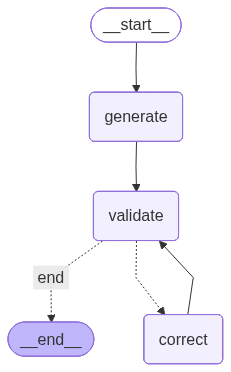

In [90]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback if dependencies are missing
    print(app.get_graph().draw_ascii())